In [103]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.multiclass import  OneVsOneClassifier, OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import  Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict, RandomizedSearchCV
from scipy.stats import randint
from sklearn.neighbors import KNeighborsClassifier

In [104]:
wine = load_wine(as_frame=True)
wine.target.value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [105]:
wineX = wine.data
wineY = wine.target
wineX, wineY

(     alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
 0      14.23        1.71  2.43  ...  1.04                          3.92   1065.0
 1      13.20        1.78  2.14  ...  1.05                          3.40   1050.0
 2      13.16        2.36  2.67  ...  1.03                          3.17   1185.0
 3      14.37        1.95  2.50  ...  0.86                          3.45   1480.0
 4      13.24        2.59  2.87  ...  1.04                          2.93    735.0
 ..       ...         ...   ...  ...   ...                           ...      ...
 173    13.71        5.65  2.45  ...  0.64                          1.74    740.0
 174    13.40        3.91  2.48  ...  0.70                          1.56    750.0
 175    13.27        4.28  2.26  ...  0.59                          1.56    835.0
 176    13.17        2.59  2.37  ...  0.60                          1.62    840.0
 177    14.13        4.10  2.74  ...  0.61                          1.60    560.0
 
 [178 rows x 1

In [106]:
wineX.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [107]:
modelPipeline = Pipeline(
    [
        ("Scale", StandardScaler()),
        ("Model", OneVsRestClassifier(SVC(random_state=67, kernel="poly", degree=5, C=10, tol=0.00000001)))
    ]
)

In [108]:
predictions = cross_val_predict(modelPipeline,X=wineX, y=wineY, cv=17, n_jobs=-1)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [109]:
accuracy_score(wineY, predictions)

0.9606741573033708

In [110]:
params = {
    "Model__estimator__degree":randint(1, 11),
    "Model__estimator__C": [1, 5, 10, 20, 50]
}
searchModel = RandomizedSearchCV(
    estimator=modelPipeline,
    param_distributions=params,
    n_iter=500,
    cv=17,
    scoring="accuracy",
    random_state=67,
    n_jobs=11,
    refit=True,

)

In [111]:
searchModel.fit(wineX, wineY)

,estimator,Pipeline(step...tol=1e-08)))])
,param_distributions,"{'Model__estimator__C': [1, 5, ...], 'Model__estimator__degree': <scipy.stats....x7f8cbc0ce780>}"
,n_iter,500
,scoring,'accuracy'
,n_jobs,11
,refit,True
,cv,17
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,67
,error_score,nan


In [112]:
rDF = pd.DataFrame(searchModel.cv_results_).set_index("rank_test_score")
rDF.sort_index()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_Model__estimator__C,param_Model__estimator__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,split10_test_score,split11_test_score,split12_test_score,split13_test_score,split14_test_score,split15_test_score,split16_test_score,mean_test_score,std_test_score
rank_test_score,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.009163,0.000609,0.002347,0.000139,1,3,"{'Model__estimator__C': 1, 'Model__estimator__...",1.000000,0.909091,1.000000,0.909091,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,0.9,1.0,1.0,1.0,1.0,1.0,0.983422,0.035857
1,0.008505,0.000795,0.002216,0.000157,5,1,"{'Model__estimator__C': 5, 'Model__estimator__...",1.000000,1.000000,0.909091,1.000000,1.000000,1.000000,0.909091,1.000000,1.0,0.9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983422,0.035857
1,0.009009,0.001727,0.002353,0.000129,5,1,"{'Model__estimator__C': 5, 'Model__estimator__...",1.000000,1.000000,0.909091,1.000000,1.000000,1.000000,0.909091,1.000000,1.0,0.9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983422,0.035857
1,0.009047,0.000288,0.002327,0.000073,1,3,"{'Model__estimator__C': 1, 'Model__estimator__...",1.000000,0.909091,1.000000,0.909091,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,0.9,1.0,1.0,1.0,1.0,1.0,0.983422,0.035857
1,0.008754,0.001635,0.002258,0.000146,5,1,"{'Model__estimator__C': 5, 'Model__estimator__...",1.000000,1.000000,0.909091,1.000000,1.000000,1.000000,0.909091,1.000000,1.0,0.9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.983422,0.035857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.010077,0.000963,0.002408,0.000260,1,10,"{'Model__estimator__C': 1, 'Model__estimator__...",0.727273,0.636364,0.909091,0.636364,0.636364,0.636364,0.636364,0.727273,0.8,0.7,0.9,0.7,0.7,0.8,0.7,0.8,0.9,0.737968,0.094230
495,0.009137,0.001725,0.002147,0.000350,1,10,"{'Model__estimator__C': 1, 'Model__estimator__...",0.727273,0.636364,0.909091,0.636364,0.636364,0.636364,0.636364,0.727273,0.8,0.7,0.9,0.7,0.7,0.8,0.7,0.8,0.9,0.737968,0.094230
495,0.010223,0.000201,0.002381,0.000067,1,10,"{'Model__estimator__C': 1, 'Model__estimator__...",0.727273,0.636364,0.909091,0.636364,0.636364,0.636364,0.636364,0.727273,0.8,0.7,0.9,0.7,0.7,0.8,0.7,0.8,0.9,0.737968,0.094230


In [113]:
finalModel = searchModel.best_estimator_
predictions= finalModel.predict(wineX)

In [114]:
str(round(accuracy_score(wineY, predictions)*100, 0))+"%"

'100.0%'

In [115]:
modelPipeline = Pipeline(
    [
        ("Scale", StandardScaler()),
        ("Model", OneVsRestClassifier(SVC(random_state=67, kernel="poly", degree=3, C=1, tol=0.00000001)))
    ]
)

In [116]:
predictions = cross_val_predict(modelPipeline,X=wineX, y=wineY, cv=17, n_jobs=-1)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [117]:
str(round(accuracy_score(wineY, predictions)*100, 3))+"%"

'98.315%'

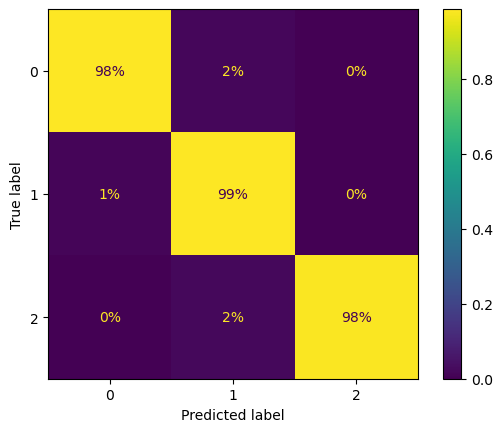

In [118]:
ConfusionMatrixDisplay.from_predictions(wineY, predictions, normalize="true", values_format=".0%")

In [119]:
modelPipeline = Pipeline(
    [
        ("Scale", StandardScaler()),
        ("Model", OneVsRestClassifier(OneVsRestClassifier(KNeighborsClassifier(n_neighbors=51, weights="distance", p=2))))
    ]
)
predictions = cross_val_predict(modelPipeline,X=wineX, y=wineY, cv=17, n_jobs=-1)
str(round(accuracy_score(wineY, predictions)*100, 10))+"%"

'97.7528089888%'

In [120]:
print(classification_report(wineY, predictions))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        59
           1       1.00      0.94      0.97        71
           2       0.98      1.00      0.99        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178



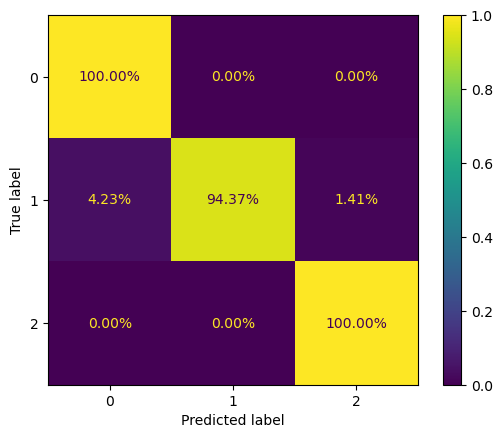

In [121]:
ConfusionMatrixDisplay.from_predictions(wineY, predictions, normalize="true", values_format=".2%")